Checkerboard:  [ 0 15  5] , Detected for params:  5 1 1
Checkerboard:  [ 1  7 11] , Detected for params:  5 0 1
Checkerboard:  [ 0  7 11] , Detected for params:  6 0 1
Checkerboard:  [4 5 7] , Detected for params:  5 0 1
Checkerboard:  [3 5 7] , Detected for params:  5 0 2
Checkerboard:  [2 5 7] , Detected for params:  5 0 3
Checkerboard:  [1 5 7] , Detected for params:  5 1 1
Checkerboard:  [0 5 7] , Detected for params:  5 1 2
Checkerboard:  [4 7 5] , Detected for params:  5 0 1
Checkerboard:  [3 7 5] , Detected for params:  5 0 2
Checkerboard:  [2 7 5] , Detected for params:  5 0 3
Checkerboard:  [1 7 5] , Detected for params:  5 1 1
Checkerboard:  [0 7 5] , Detected for params:  5 1 2
All checkerboards detected image:  calib/image_02/data\0000000000.png
Checkerboard:  [ 0 15  5] , Detected for params:  5 0 2
Checkerboard:  [ 1  7 11] , Detected for params:  5 0 1
Checkerboard:  [ 0  7 11] , Detected for params:  6 0 1
Checkerboard:  [4 5 7] , Detected for params:  5 0 1
Checkerboar

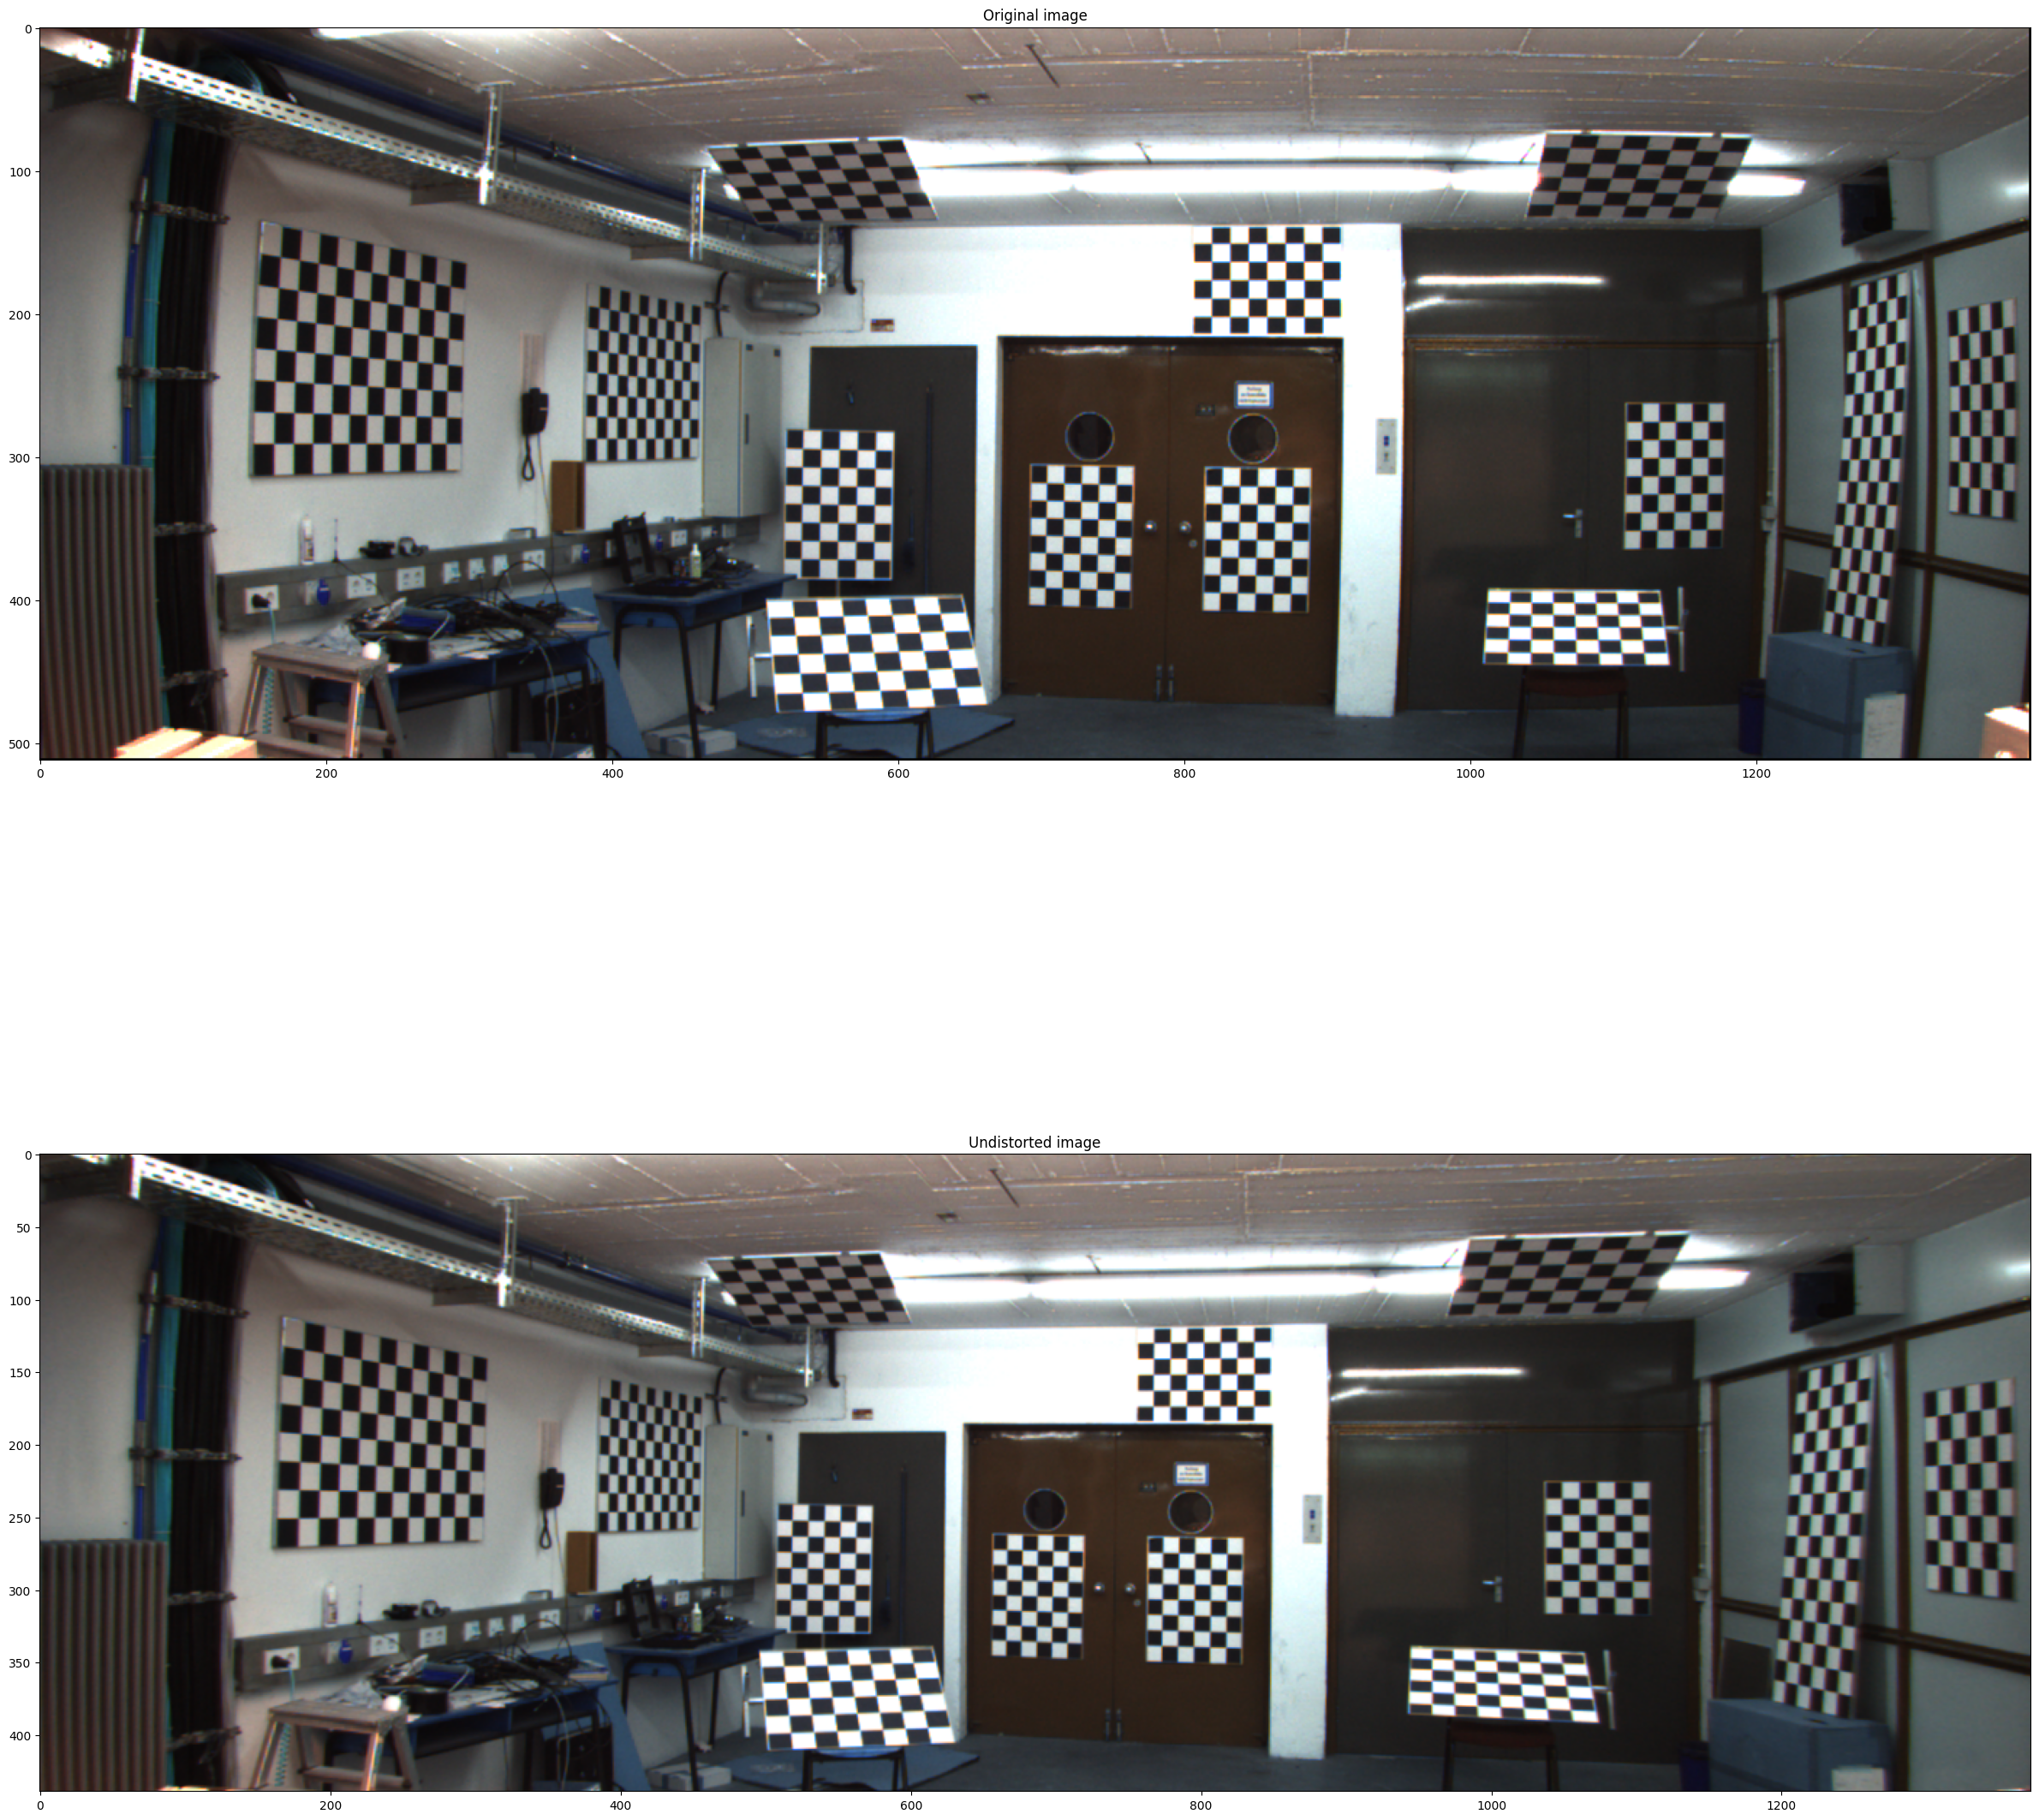

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import glob


# Checkerboard sizes, the first value is the number of checkerboards of specified size, the second is the vertical size and the last is the horizontal size
checkerboard_sizes = [(1,15,5), (2,7,11), (5,5,7), (5,7,5)]

images_left = glob.glob('calib/image_02/data/*.png')
images_right = glob.glob('calib/image_03/data/*.png')


# Check for only 5 images
images_left = images_left[:5]

# From [[0, -0.25, 0], [-0.25, 2, -0.25], [0, -0.25, 0]]
#sharpening_kernel_count = 10
# From (3,3), ...
#gauss_sizes_count = 3

def search_for_optimal_kernel(images, sharpening_kernel_count, filter_size_max):
    corners_for_all_pics = []
    object_points_for_all_pics = []
    starting_sharpening_kernel = 5
    starting_filter_size = 0
    starting_clip_Limit = 1
    
    # Loop for all the images
    for name in images:
        
        checkerboard_sizes_copy = np.array(checkerboard_sizes)
        checkerboard_points = []
        checkerboards_detected = 0
        allCheckerboard_detected = False
        
        # Loop for all the different sizes in checkerboard_sizes
        for size_number in range(len(checkerboard_sizes_copy)):
            
            # Loop for all the instances of the same checkerboard size
            for c in range(checkerboard_sizes_copy[size_number][0]):
                
                size = (checkerboard_sizes_copy[size_number][1], checkerboard_sizes_copy[size_number][2])
                
                chessboard_coords = np.zeros((size[0] * size[1], 3), np.float32)
                chessboard_coords[:, :2] = np.mgrid[0:size[0], 0:size[1]].T.reshape(-1, 2)
                
                allSizes_detected = False
                
                # Loop for different values of sharpening kernel
                for i in range(starting_sharpening_kernel, sharpening_kernel_count):
                    
                    
                    # Calculate sharpening kernel
                    sides = -0.25*(i+1) + 0.25
                    sharpening_kernel = np.array([[0, sides, 0], [sides, i+1, sides], [0, sides, 0]])
                    
                    
                    # Loop for different values of gauss blur filter
                    for j in range(starting_filter_size, filter_size_max):
                        filter_size = j * 2 + 1

                        
                        # Loop for different clip limit values for CLAHE
                        for clip_Limit in range(starting_clip_Limit, 4):
                            
                            
                        
                            img = cv.imread(name)
                            gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                            
                        
                            clahe = cv.createCLAHE(clipLimit=clip_Limit*2, tileGridSize=(16, 16))
                            gray = clahe.apply(gray)
                            gray = cv.GaussianBlur(gray, (filter_size, filter_size), 0)
                            gray = cv.filter2D(gray, -1, sharpening_kernel)
                            
                            
                            
                            # Masking the checkerboards that were detected
                            for checkerboard in checkerboard_points:
                                for p in range(len(checkerboard)):
                                    if p < len(checkerboard) -1:
                                        cv.line(gray, checkerboard[p], checkerboard[p+1], color = (0,0,0), thickness=20)
                                    else:
                                        cv.line(gray, checkerboard[0], checkerboard[p], color = (0,0,0), thickness=20)

                                cv.fillConvexPoly(gray, checkerboard, color=(0,0,0))
                            
                            cv.imshow('img',gray)
                            cv.waitKey(1)
                            
                            
                                        

                            ret, corners = cv.findChessboardCorners(gray, (size), cv.CALIB_CB_ADAPTIVE_THRESH | cv.CALIB_CB_NORMALIZE_IMAGE)
                                            
                            if ret:
                                gray = cv.drawChessboardCorners(gray, (size), corners,ret)
                                            
                                checkerboard_point = np.array([corners[0][0], corners[size[0]-1][0], corners[-1][0], corners[size[0]*size[1]-size[0]][0]], dtype=np.int32)
                                checkerboard_points.append(checkerboard_point)
        
                                object_points_for_all_pics.append(chessboard_coords)    
                                corners_for_all_pics.append(corners)
                                
                                # Masking the checkerboard
                                for p in range(len(checkerboard_point)):
                                    if p < len(checkerboard_point) -1:
                                        cv.line(gray, checkerboard_point[p], checkerboard_point[p+1], color = (0,0,0), thickness=20)
                                    else:
                                        cv.line(gray, checkerboard_point[0], checkerboard_point[p], color = (0,0,0), thickness=20)

                                cv.fillConvexPoly(gray, checkerboard_point, color=(0,0,0))

                                        
                                checkerboards_detected += 1
                                checkerboard_sizes_copy[size_number][0] -= 1
                                
                                cv.imshow('img',gray)
                                cv.waitKey(1)
                                
                                print("Checkerboard: ", checkerboard_sizes_copy[size_number],  ", Detected for params: ",i, j, clip_Limit)
                                
                                if checkerboards_detected == 13:
                                    allCheckerboard_detected = True
                                    break
                                
                                if checkerboard_sizes_copy[size_number][0] == 0:
                                    allSizes_detected = True
                                    break
                            
                                
                            
                        if allCheckerboard_detected or allSizes_detected:
                            break
                    if allCheckerboard_detected or allSizes_detected:
                        break    
                                        
                                        
                if allCheckerboard_detected or allSizes_detected:
                    break
                else:
                    print("Couldn't detect checkerboard of size", checkerboard_sizes_copy[size_number])
                        
                    
            if allCheckerboard_detected:
                print("All checkerboards detected image: ", name)
                break 
        
                           
    # Calculate camera parameters
    print("Calibrating the camera....")
    ret, camera_matrix, dist_coeffs, rot_vecs, trans_vecs = cv.calibrateCamera(object_points_for_all_pics, corners_for_all_pics, gray.shape[::-1], None, None)                
            
            
    
    
    return camera_matrix, dist_coeffs, rot_vecs, trans_vecs





camera_matrix, dist_coeffs, rot_vecs, trans_vecs = search_for_optimal_kernel(images_left, 10, 2)


demo_img = cv.imread("calib/image_02/data/0000000000.png")
height, width, _ = demo_img.shape
print("Calculating new camera matrix.....")
new_camera_matrix, roi = cv.getOptimalNewCameraMatrix(camera_matrix, dist_coeffs, (width, height), 1, (width, height))
print("Undistorting the image")
# ==================== Undistort the image ====================
undistorted_demo_img = cv.undistort(demo_img, camera_matrix, dist_coeffs, None, new_camera_matrix)
        
# ==================== Crop the image to the valid region of interest ====================
x, y, w, h = roi
undistorted_demo_img = undistorted_demo_img[y:y+h, x:x+w]


fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(15,15))
ax[0].imshow(demo_img)
ax[0].set_title('Original image')
ax[1].imshow(undistorted_demo_img)
ax[1].set_title('Undistorted image')



cv.destroyAllWindows()